## Codificación superdensa
Alice envía **2 bits clásicos** enviando solo **1 qubit**, gracias al entrelazamiento.

In [2]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Operator
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

sim = AerSimulator()

def correr(qc, shots=1024):
    """Ejecuta un circuito en el simulador y devuelve los conteos."""
    return sim.run(transpile(qc, sim), shots=shots).result().get_counts()

Enviado: 11 | Recibido: {'11': 1024}


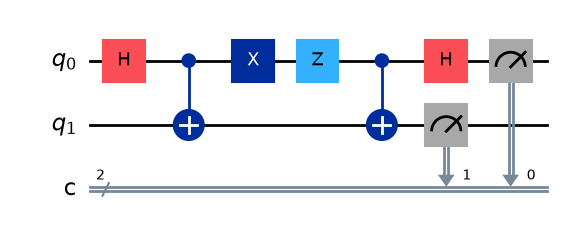

In [3]:
mensaje = "11"   # prueba "00", "01", "10", "11"

qc = QuantumCircuit(2, 2)
qc.h(0); qc.cx(0, 1)            # par de Bell compartido
if mensaje[0] == "1": qc.x(0)   # Alice codifica el primer bit con X
if mensaje[1] == "1": qc.z(0)   # y el segundo bit con Z
qc.cx(0, 1); qc.h(0)            # Bob decodifica
qc.measure([0, 1], [0, 1])

print("Enviado:", mensaje, "| Recibido:", correr(qc))
qc.draw("mpl")